# 03 Exploratory Data Analysis

Week 3 focuses on completing the ELT workflow, exploring the integrated dataset, visualizing energy consumption patterns, analyzing weather relationships, engineering early machine learning features, and documenting key findings.

## Week 3 Objectives

- Complete the ELT workflow for data preparation.
- Perform EDA on the integrated dataset.
- Visualize energy consumption trends across time and building types.
- Analyze relationships between weather variables and energy consumption.
- Engineer time-based and weather-related features for machine learning.
- Document key findings from the exploratory analysis.

## Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
processed_data_dir = project_root / "data" / "processed"
figures_dir = project_root / "figures"

cleaned_data_path = processed_data_dir / "electricity_cleaned.csv"
figures_dir.mkdir(parents=True, exist_ok=True)

cleaned_data_path

PosixPath('/Users/srs/Desktop/PROJECTS/commercial-building-energy-prediction/data/processed/electricity_cleaned.csv')

## Load Integrated Dataset

In [4]:
data = pd.read_csv(cleaned_data_path, parse_dates=["timestamp"])
data["date"] = pd.to_datetime(data["date"])

data.shape

(12060910, 20)

In [5]:
data.head()

,building_id,meter,timestamp,meter_reading,site_id,primary_use,square_feet,year_built,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,hour,day_of_week,month,is_weekend,date
0,0,0,2016-01-01,0.0,0,Education,7432,2008.0,25.0,6.0,20.0,0.0,1019.7,0.0,0.0,0,4,1,0,2016-01-01
1,1,0,2016-01-01,0.0,0,Education,2720,2004.0,25.0,6.0,20.0,0.0,1019.7,0.0,0.0,0,4,1,0,2016-01-01
2,2,0,2016-01-01,0.0,0,Education,5376,1991.0,25.0,6.0,20.0,0.0,1019.7,0.0,0.0,0,4,1,0,2016-01-01
3,3,0,2016-01-01,0.0,0,Education,23685,2002.0,25.0,6.0,20.0,0.0,1019.7,0.0,0.0,0,4,1,0,2016-01-01
4,4,0,2016-01-01,0.0,0,Education,116607,1975.0,25.0,6.0,20.0,0.0,1019.7,0.0,0.0,0,4,1,0,2016-01-01


## ELT Workflow Check

In [6]:
elt_summary = pd.DataFrame(
    [
        {"step": "Extract", "status": "Raw ASHRAE CSV files loaded from data/raw"},
        {"step": "Load", "status": "Electricity, building, and weather tables integrated"},
        {"step": "Transform", "status": "Missing values handled and time features created"},
    ]
)

elt_summary

,step,status
0,Extract,Raw ASHRAE CSV files loaded from data/raw
1,Load,"Electricity, building, and weather tables inte..."
2,Transform,Missing values handled and time features created


## Dataset Summary

In [7]:
summary = pd.Series(
    {
        "rows": len(data),
        "columns": data.shape[1],
        "buildings": data["building_id"].nunique(),
        "sites": data["site_id"].nunique(),
        "start_timestamp": data["timestamp"].min(),
        "end_timestamp": data["timestamp"].max(),
        "primary_uses": data["primary_use"].nunique(),
    }
)

pd.DataFrame(summary.items(), columns=["metric", "value"])

,metric,value
0,rows,12060910
1,columns,20
2,buildings,1413
3,sites,16
4,start_timestamp,2016-01-01 00:00:00
5,end_timestamp,2016-12-31 23:00:00
6,primary_uses,16


## Energy Consumption Trends Over Time

In [8]:
hourly_usage = data.groupby("hour", as_index=False)["meter_reading"].mean()
hourly_usage

,hour,meter_reading
0,0,149.767980
1,1,149.514803
2,2,145.749767
3,3,144.769748
4,4,145.608994
5,5,150.333052
6,6,158.605425
7,7,168.216926
8,8,175.592923
9,9,182.131009


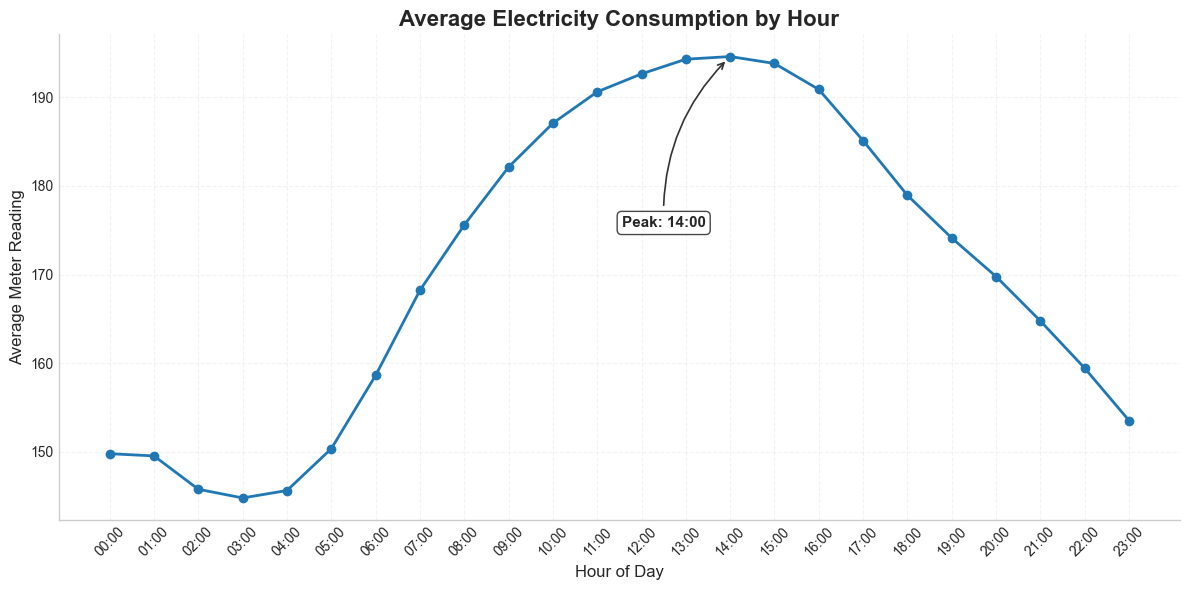

In [9]:
with plt.style.context("seaborn-v0_8-whitegrid"):
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        hourly_usage["hour"],
        hourly_usage["meter_reading"],
        marker="o",
        color="#1f77b4",
        linewidth=2,
        markersize=6,
    )

    peak_idx = hourly_usage["meter_reading"].idxmax()
    peak_hour = int(hourly_usage.loc[peak_idx, "hour"])
    peak_value = float(hourly_usage.loc[peak_idx, "meter_reading"])

    ax.annotate(
        f"Peak: {peak_hour:02d}:00",
        xy=(peak_hour, peak_value),
        xytext=(peak_hour - 1.5, peak_value - 18),
        textcoords="data",
        arrowprops=dict(
            arrowstyle="->",
            color="#333333",
            linewidth=1.2,
            connectionstyle="arc3,rad=-0.22",
            shrinkA=4,
            shrinkB=5,
        ),
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="center",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#333333",
            linewidth=1,
            alpha=0.9,
        ),
    )

    ax.set_title(
        "Average Electricity Consumption by Hour",
        fontsize=16,
        weight="bold",
    )
    ax.set_xlabel("Hour of Day", fontsize=12)
    ax.set_ylabel("Average Meter Reading", fontsize=12)

    ax.set_xticks(range(24))
    ax.set_xticklabels(
        [f"{h:02d}:00" for h in range(24)],
        rotation=45,
    )

    ax.grid(True, alpha=0.25, linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()

In [10]:
monthly_usage = data.groupby("month", as_index=False)["meter_reading"].mean()
monthly_usage

,month,meter_reading
0,1,149.312766
1,2,154.980076
2,3,149.326638
3,4,148.438191
4,5,157.954128
5,6,183.959088
6,7,189.002368
7,8,194.161618
8,9,193.295745
9,10,173.337571


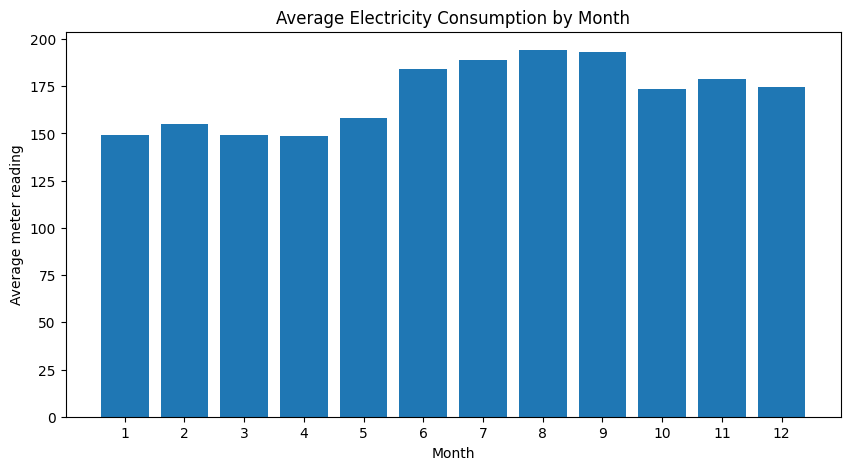

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(monthly_usage["month"], monthly_usage["meter_reading"])
ax.set_title("Average Electricity Consumption by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average meter reading")
ax.set_xticks(range(1, 13))
plt.show()

## Energy Consumption by Building Type

In [12]:
primary_use_usage = (
    data.groupby("primary_use")
    .agg(
        average_meter_reading=("meter_reading", "mean"),
        median_meter_reading=("meter_reading", "median"),
        building_count=("building_id", "nunique"),
    )
    .sort_values("average_meter_reading", ascending=False)
    .reset_index()
)

primary_use_usage

,primary_use,average_meter_reading,median_meter_reading,building_count
0,Healthcare,297.179204,164.77100,21
1,Education,245.430567,93.75000,537
2,Utility,169.304692,59.65125,4
3,Office,157.500952,64.00000,269
4,Retail,138.683212,27.86105,11
5,Entertainment/public assembly,116.197158,31.33000,179
6,Lodging/residential,108.596272,58.75010,145
7,Technology/science,107.892623,102.00200,6
8,Public services,98.712629,36.74000,155
9,Food sales and service,94.794985,72.00000,5


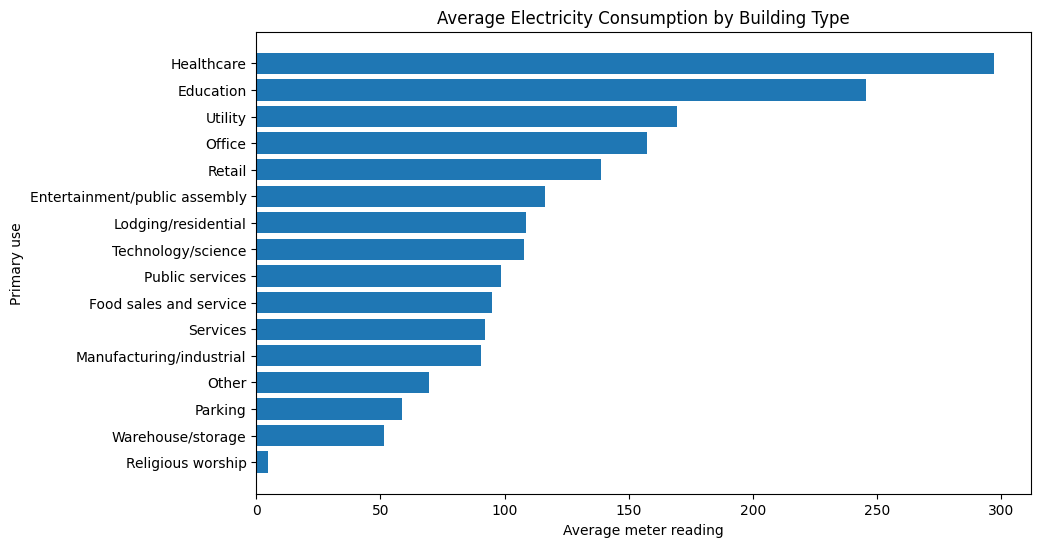

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(primary_use_usage["primary_use"], primary_use_usage["average_meter_reading"])
ax.set_title("Average Electricity Consumption by Building Type")
ax.set_xlabel("Average meter reading")
ax.set_ylabel("Primary use")
ax.invert_yaxis()
plt.show()

## Weather Variables and Energy Consumption

In [14]:
weather_columns = [
    "air_temperature",
    "cloud_coverage",
    "dew_temperature",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
]

weather_correlations = (
    data[weather_columns + ["meter_reading"]]
    .corr(numeric_only=True)["meter_reading"]
    .drop("meter_reading")
    .sort_values(ascending=False)
)

weather_correlations.reset_index().rename(
    columns={"index": "weather_variable", "meter_reading": "correlation"}
)

,weather_variable,correlation
0,precip_depth_1_hr,0.006389
1,cloud_coverage,0.002390
2,wind_direction,-0.001762
3,dew_temperature,-0.002761
4,air_temperature,-0.008719
5,sea_level_pressure,-0.013551
6,wind_speed,-0.021902


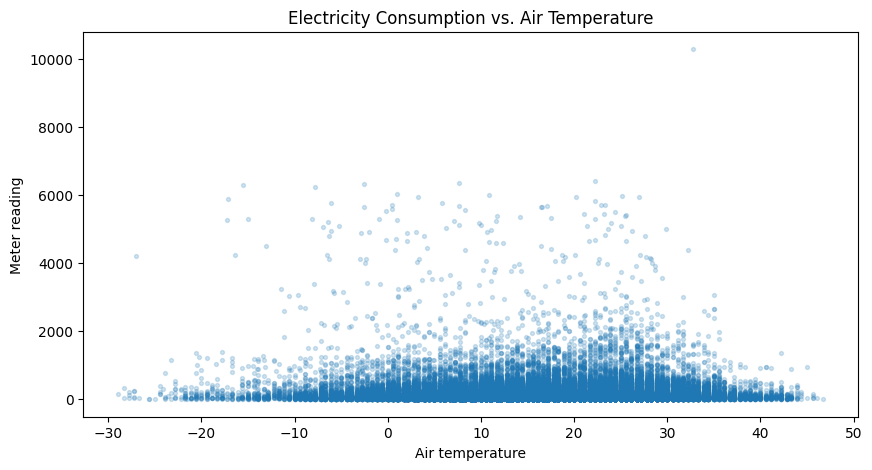

In [15]:
sample_for_scatter = data.sample(n=min(50_000, len(data)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(
    sample_for_scatter["air_temperature"],
    sample_for_scatter["meter_reading"],
    alpha=0.2,
    s=8,
)
ax.set_title("Electricity Consumption vs. Air Temperature")
ax.set_xlabel("Air temperature")
ax.set_ylabel("Meter reading")
plt.show()

In [16]:
building_type_temperature_corr = (
    data.groupby("primary_use")
    .apply(
        lambda group: group["meter_reading"].corr(group["air_temperature"])
    )
    .sort_values(ascending=False)
    .reset_index()
)

building_type_temperature_corr.columns = [
    "primary_use",
    "temperature_correlation"
]

building_type_temperature_corr

,primary_use,temperature_correlation
0,Utility,0.499235
1,Retail,0.215886
2,Lodging/residential,0.152133
3,Other,0.082836
4,Services,0.080424
5,Entertainment/public assembly,0.065029
6,Healthcare,0.037369
7,Office,0.019371
8,Warehouse/storage,0.007721
9,Parking,-0.009951


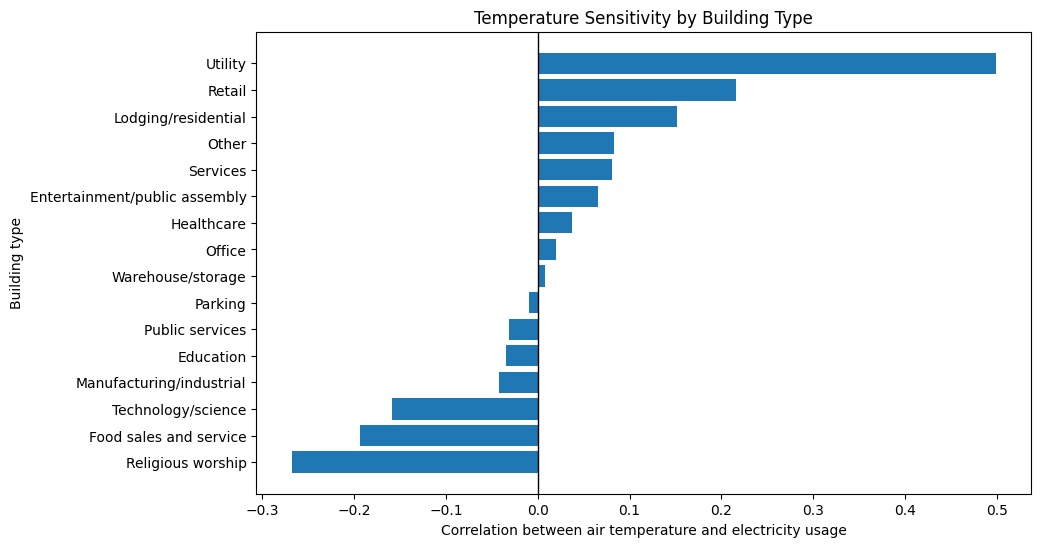

In [31]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    building_type_temperature_corr["primary_use"],
    building_type_temperature_corr["temperature_correlation"]
)

ax.set_title("Temperature Sensitivity by Building Type")
ax.set_xlabel("Correlation between air temperature and electricity usage")
ax.set_ylabel("Building type")
ax.axvline(0, color="black", linewidth=1)
ax.invert_yaxis()

plt.show()

## Feature Engineering for Machine Learning

In [17]:
eda_features = data.copy()

eda_features["is_business_hour"] = eda_features["hour"].between(8, 18).astype(int)
eda_features["is_high_temperature"] = (
    eda_features["air_temperature"] >= eda_features["air_temperature"].quantile(0.75)
).astype(int)
eda_features["temperature_difference"] = (
    eda_features["air_temperature"] - eda_features["dew_temperature"]
)

eda_features[[
    "timestamp",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_business_hour",
    "is_high_temperature",
    "temperature_difference",
]].head()

,timestamp,hour,day_of_week,month,is_weekend,is_business_hour,is_high_temperature,temperature_difference
0,2016-01-01,0,4,1,0,0,1,5.0
1,2016-01-01,0,4,1,0,0,1,5.0
2,2016-01-01,0,4,1,0,0,1,5.0
3,2016-01-01,0,4,1,0,0,1,5.0
4,2016-01-01,0,4,1,0,0,1,5.0


In [32]:
def classify_weather(row):
    if row["precip_depth_1_hr"] > 0:
        return "Rainy"
    elif row["cloud_coverage"] >= 6:
        return "Cloudy"
    elif row["cloud_coverage"] >= 3:
        return "Partly cloudy"
    elif row["air_temperature"] >= 30:
        return "Hot"
    elif row["air_temperature"] <= 5:
        return "Cold"
    elif row["wind_speed"] >= 8:
        return "Windy"
    else:
        return "Clear"

In [33]:
data["weather_condition"] = data.apply(classify_weather, axis=1)

data["weather_condition"].value_counts()

weather_condition
Clear            6260433
Partly cloudy    2128750
Cold             1365657
Cloudy            967332
Hot               624087
Rainy             479241
Windy             235410
Name: count, dtype: int64

## Daily Peak Demand Exploration

In [18]:
daily_peak = data.loc[
    data.groupby(["building_id", "date"])["meter_reading"].idxmax(),
    ["building_id", "date", "hour", "meter_reading", "primary_use"],
].rename(
    columns={
        "hour": "peak_hour",
        "meter_reading": "peak_meter_reading",
    }
)

daily_peak.head()

,building_id,date,peak_hour,peak_meter_reading,primary_use
0,0,2016-01-01,0,0.0,Education
33300,0,2016-01-02,0,0.0,Education
66611,0,2016-01-03,0,0.0,Education
99958,0,2016-01-04,0,0.0,Education
133256,0,2016-01-05,0,0.0,Education


In [19]:
peak_hour_counts = (
    daily_peak["peak_hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)
peak_hour_counts.columns = ["peak_hour", "count"]

peak_hour_counts

,peak_hour,count
0,0,61285
1,1,7663
2,2,5363
3,3,4530
4,4,3975
5,5,5247
6,6,8154
7,7,11961
8,8,12175
9,9,16890


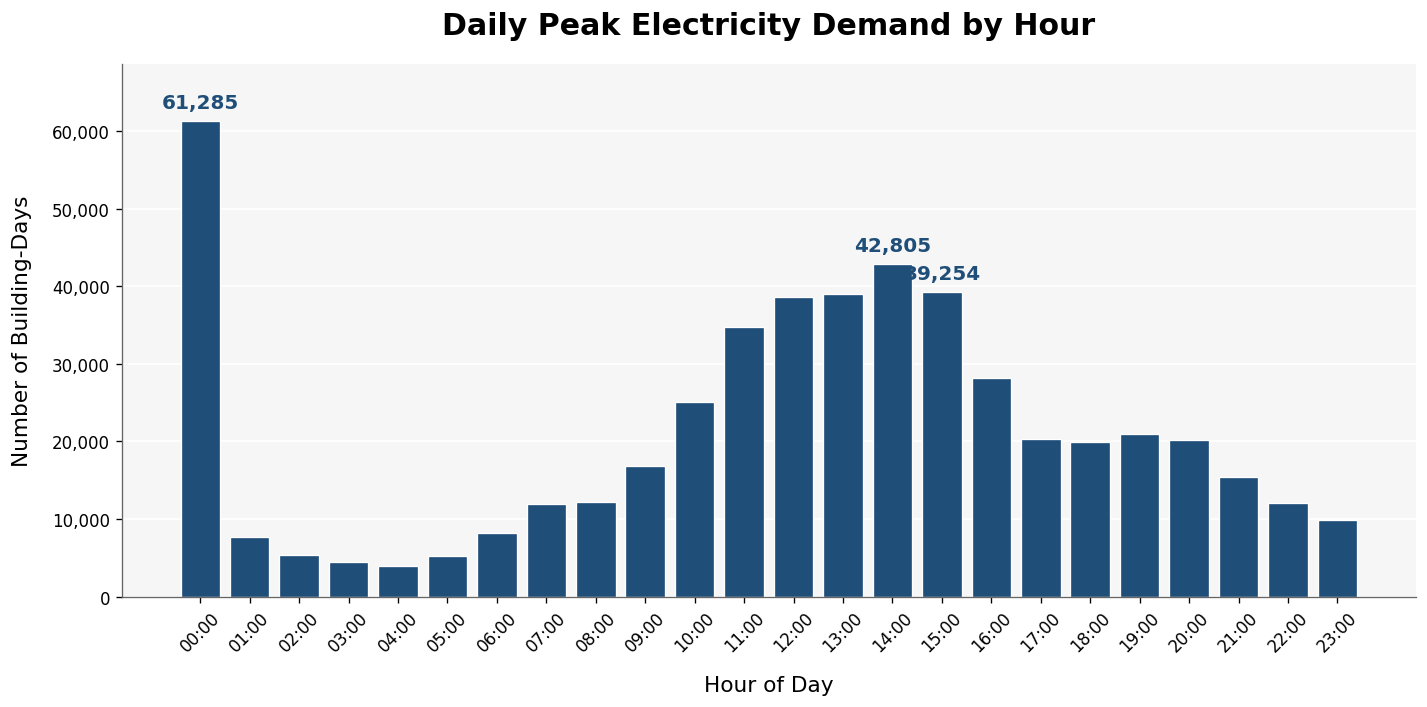

In [20]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
fig.patch.set_facecolor("white")
ax.set_facecolor("#f6f6f6")

bars = ax.bar(
    peak_hour_counts["peak_hour"],
    peak_hour_counts["count"],
    color="#1f4e79",
    edgecolor="white",
    linewidth=0.8,
)

ax.set_title(
    "Daily Peak Electricity Demand by Hour",
    fontsize=18,
    weight="bold",
    pad=18,
)
ax.set_xlabel("Hour of Day", fontsize=13, labelpad=12)
ax.set_ylabel("Number of Building-Days", fontsize=13, labelpad=12)

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)
ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.yaxis.set_major_formatter(lambda x, pos: f"{int(x):,}")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")
ax.grid(axis="y", color="white", linestyle="-", linewidth=1)
ax.set_axisbelow(True)

# Add headroom so labels are not clipped
ax.set_ylim(0, peak_hour_counts["count"].max() * 1.12)

# Label the top 3 peak hours
top_hours = peak_hour_counts.nlargest(3, "count")

for _, row in top_hours.iterrows():
    ax.text(
        row["peak_hour"],
        row["count"] + peak_hour_counts["count"].max() * 0.02,
        f"{row['count']:,}",
        ha="center",
        va="bottom",
        fontsize=12,
        color="#1f4e79",
        fontweight="bold",
        clip_on=False,
        zorder=5,
    )

plt.tight_layout()
fig.savefig(
    figures_dir / "daily_peak_hour_distribution.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [21]:
daily_counts = (
    data.groupby(["building_id", "date"])
    .agg(
        hourly_records=("hour", "count"),
        unique_readings=("meter_reading", "nunique"),
        max_reading=("meter_reading", "max"),
        min_reading=("meter_reading", "min"),
    )
    .reset_index()
)

daily_counts.head()

,building_id,date,hourly_records,unique_readings,max_reading,min_reading
0,0,2016-01-01,24,1,0.0,0.0
1,0,2016-01-02,24,1,0.0,0.0
2,0,2016-01-03,24,1,0.0,0.0
3,0,2016-01-04,24,1,0.0,0.0
4,0,2016-01-05,24,1,0.0,0.0


In [22]:
flat_day_summary = daily_counts.copy()

flat_day_summary["day_type"] = "Variable readings"
flat_day_summary.loc[
    flat_day_summary["unique_readings"] == 1,
    "day_type"
] = "Flat readings"

flat_day_summary.loc[
    (flat_day_summary["unique_readings"] == 1)
    & (flat_day_summary["max_reading"] == 0),
    "day_type"
] = "Flat zero readings"

flat_day_summary["day_type"].value_counts()

day_type
Variable readings     457217
Flat readings          27643
Flat zero readings     19006
Name: count, dtype: int64

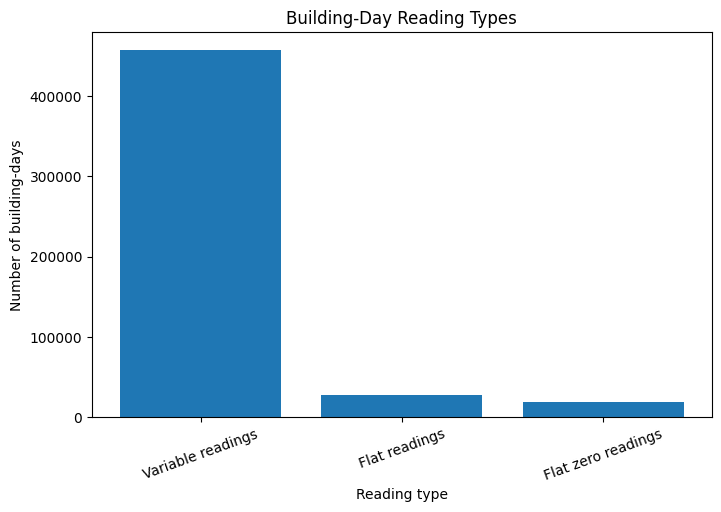

In [23]:
day_type_counts = (
    flat_day_summary["day_type"]
    .value_counts()
    .reset_index()
)

day_type_counts.columns = ["day_type", "count"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(day_type_counts["day_type"], day_type_counts["count"])

ax.set_title("Building-Day Reading Types")
ax.set_xlabel("Reading type")
ax.set_ylabel("Number of building-days")
ax.tick_params(axis="x", rotation=20)

plt.show()

In [24]:
daily_peak_with_counts = daily_peak.merge(
    daily_counts,
    on=["building_id", "date"],
    how="left"
)

hour_zero_breakdown = daily_peak_with_counts[
    daily_peak_with_counts["peak_hour"] == 0
].copy()

hour_zero_breakdown["reason"] = "Variable readings"
hour_zero_breakdown.loc[
    hour_zero_breakdown["unique_readings"] == 1,
    "reason"
] = "Flat readings"

hour_zero_breakdown.loc[
    (hour_zero_breakdown["unique_readings"] == 1)
    & (hour_zero_breakdown["max_reading"] == 0),
    "reason"
] = "Flat zero readings"

hour_zero_reason_counts = (
    hour_zero_breakdown["reason"]
    .value_counts()
    .reset_index()
)

hour_zero_reason_counts.columns = ["reason", "count"]

hour_zero_reason_counts

,reason,count
0,Flat readings,27524
1,Flat zero readings,18914
2,Variable readings,14847


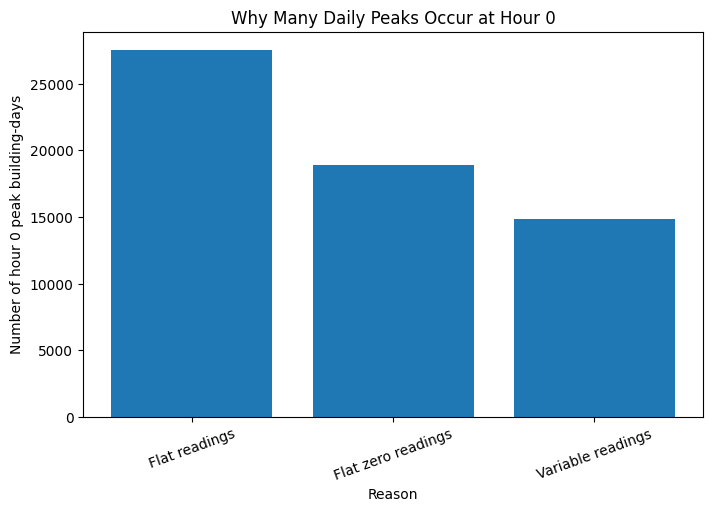

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(hour_zero_reason_counts["reason"], hour_zero_reason_counts["count"])

ax.set_title("Why Many Daily Peaks Occur at Hour 0")
ax.set_xlabel("Reason")
ax.set_ylabel("Number of hour 0 peak building-days")
ax.tick_params(axis="x", rotation=20)

plt.show()

In [26]:
valid_peak_days = daily_counts[
    (daily_counts["hourly_records"] == 24)
    & (daily_counts["unique_readings"] > 1)
].copy()

valid_data = data.merge(
    valid_peak_days[["building_id", "date"]],
    on=["building_id", "date"],
    how="inner"
)

daily_peak_valid = valid_data.loc[
    valid_data.groupby(["building_id", "date"])["meter_reading"].idxmax(),
    ["building_id", "date", "hour", "meter_reading", "primary_use"],
].rename(
    columns={
        "hour": "peak_hour",
        "meter_reading": "peak_meter_reading",
    }
)

daily_peak_valid.head()

,building_id,date,peak_hour,peak_meter_reading,primary_use
820208,0,2016-01-30,8,43.6839,Education
849209,0,2016-01-31,17,52.5571,Education
2640158,0,2016-04-08,14,59.3827,Education
3295027,0,2016-05-01,19,448.0000,Education
3841915,0,2016-05-20,19,277.8020,Education


In [27]:
peak_hour_counts_valid = (
    daily_peak_valid["peak_hour"]
    .value_counts()
    .sort_index()
    .reset_index()
)

peak_hour_counts_valid.columns = ["peak_hour", "count"]

peak_hour_counts_valid

,peak_hour,count
0,0,14677
1,1,7501
2,2,5313
3,3,4476
4,4,3929
5,5,5189
6,6,7998
7,7,11808
8,8,11897
9,9,16606


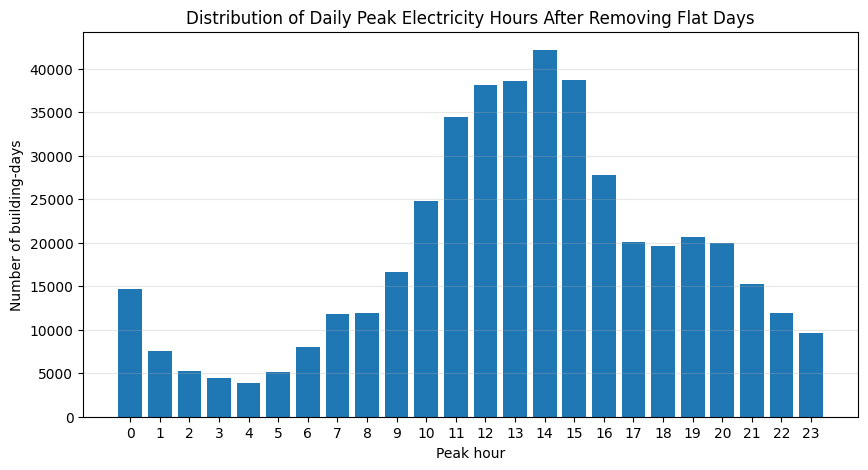

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    peak_hour_counts_valid["peak_hour"],
    peak_hour_counts_valid["count"],
)

ax.set_title("Distribution of Daily Peak Electricity Hours After Removing Flat Days")
ax.set_xlabel("Peak hour")
ax.set_ylabel("Number of building-days")
ax.set_xticks(range(24))
ax.grid(axis="y", alpha=0.3)

plt.show()

In [29]:
peak_hour_comparison = peak_hour_counts.merge(
    peak_hour_counts_valid,
    on="peak_hour",
    how="outer",
    suffixes=("_original", "_valid")
).fillna(0)

peak_hour_comparison

,peak_hour,count_original,count_valid
0,0,61285,14677
1,1,7663,7501
2,2,5363,5313
3,3,4530,4476
4,4,3975,3929
5,5,5247,5189
6,6,8154,7998
7,7,11961,11808
8,8,12175,11897
9,9,16890,16606


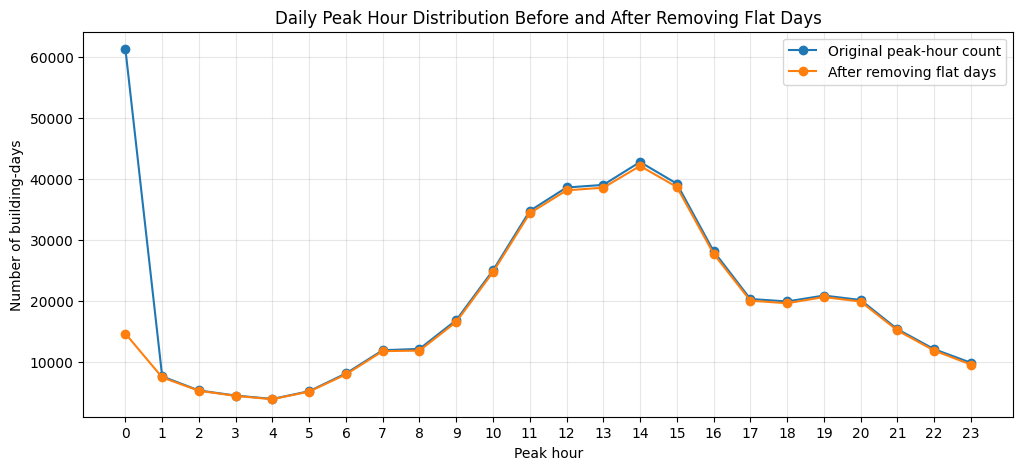

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    peak_hour_comparison["peak_hour"],
    peak_hour_comparison["count_original"],
    marker="o",
    label="Original peak-hour count",
)

ax.plot(
    peak_hour_comparison["peak_hour"],
    peak_hour_comparison["count_valid"],
    marker="o",
    label="After removing flat days",
)

ax.set_title("Daily Peak Hour Distribution Before and After Removing Flat Days")
ax.set_xlabel("Peak hour")
ax.set_ylabel("Number of building-days")
ax.set_xticks(range(24))
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

## Key Findings

Document the main findings from Week 3 EDA here. Suggested points to complete after running the notebook:

- Time periods with the highest average electricity consumption.
- Building types with the highest average electricity consumption.
- Weather variables most related to electricity consumption.
- Common hours for daily peak demand.
- Feature engineering choices that should move forward into machine learning.